# Snoozy Meditation Classifier

Binary classifier: **meditation vs. mind-wandering** from the OpenNeuro ds001787 probed EEG sessions.

Hardware target: **nRF54L15 + ADS1299-4 + BNO086**

Design choices:
- 10-second window before each probe onset
- 4 EEG channels selected from the research dataset to match the wearable electrode positions (Fp1, Fp2, AF7, AF8)
- Real-time-computable features: per-channel PSD bands, sub-bands, ratios, Hjorth params, spectral entropy, ZCR + cross-channel coherence and asymmetry
- Leave-One-Participant-Out (LOPO) cross-validation
- Export to ONNX for on-device inference

**Referencing note:** each ADS1299 input is wired as `FpX(+) / AFz(−)` so both channels share a common midline forehead reference. This gives the ADS1299's differential CMRR without collapsing to a single bipolar channel. The cross-channel asymmetry features (log Fp2_α − log Fp1_α, etc.) capture the same lateralization information that a hardware Fp1−Fp2 bipolar would, while keeping both channels available for per-channel features.

## Imports

In [1]:
from __future__ import annotations

import json
import math
import time
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import joblib
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from scipy.signal import coherence, welch
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("ERROR")

## Configuration

In [2]:
DATA_ROOT = Path("dataset/ds001787")
ARTIFACTS_DIR = Path("artifacts")

# --- EEG window ---
CONTEXT_SEC  = 10.0  # pre-probe context: total duration to extract sliding windows from
WINDOW_SEC   = 5.0   # feature window length (each sliding window)
STEP_SEC     = 0.5   # step between consecutive windows → 11 windows per probe
N_SUBWINDOWS = 5     # split each window into N chunks for intra-window variability features
LOWCUT       = 0.5   # Hz  (bandpass pre-processing)
HIGHCUT      = 40.0  # Hz

# --- Channel selection ---
# BioSemi labelling: A1=Fp1, B2=Fp2, A2=AF7, B3=AF8, B1=Fpz
# ADS1299-4 differential inputs:
#   Ch1: (Fp1−Fp2)  Ch2: (AF7−AF8)  BIAS/REF: Fpz
# We compute (Fp1−Fp2)−Fpz and (AF7−AF8)−Fpz to match the hardware derivation.
PRIMARY_CHANNELS  = ["A1", "B2", "A2", "B3"]  # Fp1, Fp2, AF7, AF8 (needed for bipolars)
REFERENCE_CHANNEL = "B1"                        # Fpz — subtracted from each bipolar pair
BIPOLAR_LABELS    = ["Fp1-Fp2", "AF7-AF8"]     # logical channel names for feature naming
N_CHANNELS_REQUIRED = 4                         # all 4 primaries must be present

# --- Label mapping ---
Q2_LABEL: Dict[int, str] = {2: "meditation", 4: "mind_wandering", 8: "mind_wandering"}
TARGET_LABELS = ["meditation", "mind_wandering"]

# --- Spectral bands ---
BANDS = {
    "delta":  (0.5,  4.0),
    "theta":  (4.0,  8.0),
    "alpha":  (8.0, 12.0),
    "sigma":  (12.0, 16.0),
    "beta":   (16.0, 30.0),
}
SUB_BANDS = {
    "theta1": (4.0,  6.0),
    "theta2": (6.0,  8.0),
    "alpha1": (8.0, 10.0),
    "alpha2": (10.0, 12.0),
}

RANDOM_STATE = 42
_n_wins_per_probe = int((CONTEXT_SEC - WINDOW_SEC) / STEP_SEC) + 1
print(f"DATA_ROOT exists: {DATA_ROOT.exists()}")
print(f"Sliding windows per probe: {_n_wins_per_probe}  "
      f"({CONTEXT_SEC:.0f}s context, {WINDOW_SEC:.0f}s window, {STEP_SEC}s step)")

DATA_ROOT exists: True
Sliding windows per probe: 11  (10s context, 5s window, 0.5s step)


## Feature Extraction

All features are computable in real-time from a single 5-second window on the nRF54L15 (Cortex-M33).

Feature layout (64 total):
- **Per channel × 2** (F7, F8): 5 band abs powers, 5 rel powers, 4 band ratios, 3 Hjorth, spectral entropy, ZCR, mean/std/rms, 4 sub-band powers, theta peak freq, alpha peak freq → **32 × 2 = 64** per channel
- Subtract cross-channel features from the count: **56 per-channel + 8 cross-channel = 64 total**

In [3]:
def _band_power(psd: np.ndarray, freqs: np.ndarray, lo: float, hi: float) -> float:
    mask = (freqs >= lo) & (freqs < hi)
    return float(np.sum(psd[mask])) if np.any(mask) else 0.0


def _peak_freq(psd: np.ndarray, freqs: np.ndarray, lo: float, hi: float) -> float:
    mask = (freqs >= lo) & (freqs < hi)
    if not np.any(mask):
        return (lo + hi) / 2.0
    return float(freqs[mask][np.argmax(psd[mask])])


def _spectral_entropy(psd: np.ndarray) -> float:
    p = psd / (np.sum(psd) + 1e-12)
    return float(-np.sum(p * np.log(p + 1e-12)))


def _spectral_edge_freq(psd: np.ndarray, freqs: np.ndarray, threshold: float = 0.95) -> float:
    """SEF95: lowest frequency below which `threshold` fraction of total power lies."""
    cumsum = np.cumsum(psd)
    target = threshold * cumsum[-1]
    idx = int(np.searchsorted(cumsum, target))
    return float(freqs[min(idx, len(freqs) - 1)])


def _permutation_entropy(x: np.ndarray, order: int = 3, delay: int = 1) -> float:
    """Permutation entropy — captures ordinal complexity/irregularity of the signal.

    High PE → irregular (mind-wandering); low PE → structured (meditation).
    Runs in O(n) with a dict-based ordinal pattern counter.
    """
    n = len(x)
    run_len = delay * (order - 1)
    if n <= run_len:
        return 0.0
    counts: dict = {}
    for i in range(n - run_len):
        pattern = tuple(np.argsort(x[i: i + run_len + 1: delay], kind="stable"))
        counts[pattern] = counts.get(pattern, 0) + 1
    total = sum(counts.values())
    probs = np.array(list(counts.values()), dtype=np.float64) / total
    return float(-np.sum(probs * np.log2(probs + 1e-12)))


def _hjorth(x: np.ndarray) -> Tuple[float, float, float]:
    """Activity, Mobility, Complexity."""
    activity = float(np.var(x))
    d1 = np.diff(x)
    mobility = float(np.sqrt(np.var(d1) / (activity + 1e-12)))
    d2 = np.diff(d1)
    mob_d1 = float(np.sqrt(np.var(d2) / (np.var(d1) + 1e-12)))
    complexity = mob_d1 / (mobility + 1e-12)
    return activity, mobility, complexity


def channel_features(x: np.ndarray, fs: float) -> List[float]:
    """30 features from a single EEG channel."""
    x = x.astype(np.float64)
    nperseg = min(int(fs), len(x))
    freqs, psd = welch(x, fs=fs, nperseg=nperseg)
    total_power = float(np.sum(psd)) + 1e-12

    band_abs = {name: _band_power(psd, freqs, lo, hi) for name, (lo, hi) in BANDS.items()}
    band_rel = {name: v / total_power for name, v in band_abs.items()}

    feats: List[float] = []
    for name in BANDS:
        feats.append(band_abs[name])
    for name in BANDS:
        feats.append(band_rel[name])

    theta, alpha = band_abs["theta"], band_abs["alpha"]
    delta, beta  = band_abs["delta"],  band_abs["beta"]
    feats.append(theta / (alpha + 1e-12))
    feats.append(delta / (beta  + 1e-12))
    feats.append(alpha / (beta  + 1e-12))
    feats.append(theta / (beta  + 1e-12))

    feats.extend(_hjorth(x))
    feats.append(_spectral_entropy(psd))
    feats.append(float(np.mean(np.diff(np.signbit(x)) != 0)))
    feats.append(float(np.mean(x)))
    feats.append(float(np.std(x)))
    feats.append(float(np.sqrt(np.mean(x ** 2))))

    for lo, hi in SUB_BANDS.values():
        feats.append(_band_power(psd, freqs, lo, hi))

    feats.append(_peak_freq(psd, freqs, *BANDS["theta"]))
    feats.append(_peak_freq(psd, freqs, *BANDS["alpha"]))

    # YASA-inspired additions
    feats.append(_spectral_edge_freq(psd, freqs, 0.95))   # SEF95
    feats.append(_permutation_entropy(x, order=3, delay=1))  # PE

    return feats  # 5+5+4+3+1+1+3+4+2+2 = 30


def subwindow_features(x: np.ndarray, fs: float) -> List[float]:
    """7 intra-window variability features from a single channel.

    Splits the window into N_SUBWINDOWS equal chunks and computes:
      - std of each band power across chunks (5 features)
      - linear slope of theta and alpha across chunks (2 features)
    """
    x = x.astype(np.float64)
    n = len(x)
    chunk_size = n // N_SUBWINDOWS

    bp = np.zeros((N_SUBWINDOWS, len(BANDS)))
    for wi in range(N_SUBWINDOWS):
        chunk = x[wi * chunk_size: (wi + 1) * chunk_size]
        nperseg = min(int(fs), len(chunk))
        freqs, psd = welch(chunk, fs=fs, nperseg=nperseg)
        for bi, (lo, hi) in enumerate(BANDS.values()):
            bp[wi, bi] = _band_power(psd, freqs, lo, hi)

    feats: List[float] = list(bp.std(axis=0))  # 5: std per band across sub-windows

    t = np.arange(N_SUBWINDOWS, dtype=np.float64)
    feats.append(float(np.polyfit(t, bp[:, 1], 1)[0]))  # theta slope
    feats.append(float(np.polyfit(t, bp[:, 2], 1)[0]))  # alpha slope

    return feats  # 7 features


def cross_channel_features(eeg: np.ndarray, fs: float) -> List[float]:
    """8 features per channel pair: 3 coherence + 1 corr + 4 log-asymmetry."""
    n_ch    = eeg.shape[0]
    nperseg = min(int(fs), eeg.shape[1])
    feats: List[float] = []

    psds: List[np.ndarray] = []
    freqs_ref: np.ndarray  = None
    for i in range(n_ch):
        freqs_ref, psd = welch(eeg[i].astype(np.float64), fs=fs, nperseg=nperseg)
        psds.append(psd)

    for i in range(n_ch):
        for j in range(i + 1, n_ch):
            ch_i = eeg[i].astype(np.float64)
            ch_j = eeg[j].astype(np.float64)

            for band_name in ("theta", "alpha", "beta"):
                lo, hi = BANDS[band_name]
                f_coh, cxy = coherence(ch_i, ch_j, fs=fs, nperseg=nperseg)
                mask = (f_coh >= lo) & (f_coh < hi)
                feats.append(float(np.mean(cxy[mask])) if np.any(mask) else 0.0)

            corr = float(np.corrcoef(ch_i, ch_j)[0, 1])
            feats.append(corr if np.isfinite(corr) else 0.0)

            for band_name in ("alpha", "theta", "delta", "beta"):
                lo, hi = BANDS[band_name]
                p_i = _band_power(psds[i], freqs_ref, lo, hi)
                p_j = _band_power(psds[j], freqs_ref, lo, hi)
                feats.append(float(np.log(p_j + 1e-12) - np.log(p_i + 1e-12)))

    return feats  # 8 × n_ch*(n_ch-1)/2 pairs


def extract_features(eeg: np.ndarray, fs: float) -> np.ndarray:
    """Full feature vector for an N-channel EEG epoch (shape: N × samples)."""
    feats: List[float] = []
    for ch in range(eeg.shape[0]):
        feats.extend(channel_features(eeg[ch], fs))
    feats.extend(cross_channel_features(eeg, fs))
    for ch in range(eeg.shape[0]):
        feats.extend(subwindow_features(eeg[ch], fs))
    return np.asarray(feats, dtype=np.float32)


def feature_names(ch_names: Sequence[str]) -> List[str]:
    """Ordered list of feature names matching extract_features output."""
    names: List[str] = []
    for ch in ch_names:
        for band in BANDS:
            names.append(f"{ch}_{band}_abs")
        for band in BANDS:
            names.append(f"{ch}_{band}_rel")
        names += [f"{ch}_theta_alpha", f"{ch}_delta_beta", f"{ch}_alpha_beta", f"{ch}_theta_beta"]
        names += [f"{ch}_hjorth_act", f"{ch}_hjorth_mob", f"{ch}_hjorth_cplx"]
        names.append(f"{ch}_spec_entropy")
        names.append(f"{ch}_zcr")
        names += [f"{ch}_mean", f"{ch}_std", f"{ch}_rms"]
        for sub in SUB_BANDS:
            names.append(f"{ch}_{sub}_abs")
        names.append(f"{ch}_theta_peak_hz")
        names.append(f"{ch}_alpha_peak_hz")
        names.append(f"{ch}_sef95")
        names.append(f"{ch}_perm_entropy")

    for i, chi in enumerate(ch_names):
        for j, chj in enumerate(ch_names):
            if j <= i:
                continue
            pair = f"{chi}_{chj}"
            names += [f"coh_theta_{pair}", f"coh_alpha_{pair}", f"coh_beta_{pair}"]
            names.append(f"corr_{pair}")
            names += [f"asym_alpha_{pair}", f"asym_theta_{pair}",
                      f"asym_delta_{pair}", f"asym_beta_{pair}"]

    for ch in ch_names:
        for band in BANDS:
            names.append(f"{ch}_{band}_std_sw")
        names.append(f"{ch}_theta_slope_sw")
        names.append(f"{ch}_alpha_slope_sw")

    return names


# Smoke-test — 2 bipolar channels, 30 per-channel features
_n_ch    = len(BIPOLAR_LABELS)   # 2
_n_pairs = _n_ch * (_n_ch - 1) // 2  # 1
_n_sw    = 7
_expected = _n_ch * 30 + _n_pairs * 8 + _n_ch * _n_sw  # 60 + 8 + 14 = 82
_dummy_eeg   = np.random.randn(_n_ch, int(256 * WINDOW_SEC)).astype(np.float32)
_dummy_feats = extract_features(_dummy_eeg, fs=256.0)
_dummy_names = feature_names(BIPOLAR_LABELS)
print(f"Channels: {_n_ch}  →  {_n_ch*30} per-channel + {_n_pairs*8} cross-channel + {_n_ch*_n_sw} subwindow = {_expected} total")
print(f"Feature vector length : {len(_dummy_feats)}")
print(f"Feature names length  : {len(_dummy_names)}")
assert len(_dummy_feats) == len(_dummy_names) == _expected, \
    f"Feature count mismatch: feats={len(_dummy_feats)}, names={len(_dummy_names)}, expected={_expected}"
print("Feature extraction OK")

Channels: 2  →  60 per-channel + 8 cross-channel + 14 subwindow = 82 total
Feature vector length : 82
Feature names length  : 82
Feature extraction OK


## Dataset Loading

Selects F7 and F8 from each recording. Falls back to the best-available frontal pair if either channel is missing.

Probe label extraction follows the Q2 convention: stimulus/128 → responses → Q2 is the second response value (2=meditation, 4/8=mind_wandering). Adapted from `med_model.py`.

In [4]:
def _has_required_channels(raw: mne.io.BaseRaw) -> bool:
    """Return True if all PRIMARY_CHANNELS and REFERENCE_CHANNEL are present."""
    available = set(raw.ch_names)
    return all(ch in available for ch in PRIMARY_CHANNELS + [REFERENCE_CHANNEL])


def _extract_probe_label(events_df: pd.DataFrame, probe_idx: int) -> Optional[str]:
    """Q2 label from the response rows that follow a probe onset."""
    responses: List[int] = []
    for j in range(probe_idx + 1, len(events_df)):
        row = events_df.iloc[j]
        tt = str(row.get("trial_type", "")).strip().lower()
        val = row.get("value")
        if tt == "stimulus" and pd.notna(val) and int(val) == 128:
            break
        if tt == "response" and pd.notna(val) and int(val) in Q2_LABEL:
            responses.append(int(val))
        if len(responses) == 3:
            break
    if len(responses) < 2:
        return None
    return Q2_LABEL.get(responses[1])


def _find_recording_pairs(sub_dir: Path) -> List[Tuple[Path, Path]]:
    pairs: List[Tuple[Path, Path]] = []
    for ses_dir in sorted(sub_dir.glob("ses-*")):
        if not ses_dir.is_dir():
            continue
        eeg_dir = ses_dir / "eeg"
        if not eeg_dir.is_dir():
            continue
        for eeg_path in sorted(eeg_dir.iterdir()):
            if eeg_path.suffix.lower() not in {".edf", ".bdf", ".set", ".fif"}:
                continue
            if "task-meditation" not in eeg_path.name:
                continue
            if f"_eeg{eeg_path.suffix}" not in eeg_path.name:
                continue
            events_path = eeg_path.with_name(
                eeg_path.name.replace(f"_eeg{eeg_path.suffix}", "_events.tsv")
            )
            if events_path.exists():
                pairs.append((eeg_path, events_path))
    return pairs


def _read_raw(eeg_path: Path) -> mne.io.BaseRaw:
    readers = {".edf": mne.io.read_raw_edf, ".bdf": mne.io.read_raw_bdf,
               ".set": mne.io.read_raw_eeglab, ".fif": mne.io.read_raw_fif}
    fn = readers.get(eeg_path.suffix.lower())
    if fn is None:
        raise ValueError(f"Unsupported format: {eeg_path.suffix}")
    return fn(eeg_path, preload=True, verbose="ERROR")


def load_dataset(
    ds_root: Path,
    context_sec: float = CONTEXT_SEC,
    window_sec: float = WINDOW_SEC,
    step_sec: float = STEP_SEC,
    max_subjects: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, List[str], float]:
    """
    Returns X, y, groups, probe_ids, channel_names, sampling_freq.

    For each probe event, a sliding window is applied over the CONTEXT_SEC
    pre-probe EEG. Each WINDOW_SEC window (step STEP_SEC) yields one feature
    vector with the same Q2 label. probe_ids ties every window back to its
    originating probe so predictions can be aggregated at probe level.

    Two bipolar derivations per window:
      Ch0 = (Fp1 − Fp2) − Fpz   (A1 − B2 − B1)
      Ch1 = (AF7 − AF8) − Fpz   (A2 − B3 − B1)
    """
    subject_dirs = sorted(p for p in ds_root.glob("sub-*") if p.is_dir())
    if max_subjects is not None:
        subject_dirs = subject_dirs[:max_subjects]

    canonical_sfreq: Optional[float] = None
    all_X:         List[np.ndarray] = []
    all_y:         List[str]        = []
    all_groups:    List[str]        = []
    all_probe_ids: List[str]        = []

    load_chs = PRIMARY_CHANNELS + [REFERENCE_CHANNEL]

    for sub_dir in subject_dirs:
        pairs = _find_recording_pairs(sub_dir)
        if not pairs:
            print(f"  skip {sub_dir.name}: no meditation EEG pairs")
            continue

        subj_windows = 0
        for rec_idx, (eeg_path, events_path) in enumerate(pairs):
            try:
                raw = _read_raw(eeg_path)
            except Exception as exc:
                print(f"  skip {eeg_path.name}: {exc}")
                continue

            if not _has_required_channels(raw):
                print(f"  skip {eeg_path.name}: required channels {load_chs} not all present")
                continue

            raw.pick(load_chs)
            raw.filter(LOWCUT, HIGHCUT, verbose="ERROR")

            sfreq = float(raw.info["sfreq"])
            if canonical_sfreq is None:
                canonical_sfreq = sfreq
            elif abs(sfreq - canonical_sfreq) > 1e-6:
                raw.resample(canonical_sfreq, npad="auto")
                sfreq = canonical_sfreq

            context_samples = int(round(context_sec * sfreq))
            window_samples  = int(round(window_sec  * sfreq))
            step_samples    = int(round(step_sec    * sfreq))

            idx = {ch: raw.ch_names.index(ch) for ch in load_chs}

            try:
                events_df = pd.read_csv(events_path, sep="\t")
            except Exception as exc:
                print(f"  skip {events_path.name}: {exc}")
                continue

            if not {"onset", "trial_type", "value"}.issubset(events_df.columns):
                print(f"  skip {events_path.name}: missing required columns")
                continue

            probe_counter = 0
            for i, row in events_df.iterrows():
                tt  = str(row.get("trial_type", "")).strip().lower()
                val = row.get("value")
                if tt != "stimulus" or pd.isna(val) or int(val) != 128:
                    continue

                label = _extract_probe_label(events_df, i)
                if label not in TARGET_LABELS:
                    continue

                probe_sample  = int(round(float(row["onset"]) * sfreq))
                context_start = probe_sample - context_samples
                if context_start < 0 or probe_sample > raw.n_times:
                    continue

                probe_id = f"{sub_dir.name}_r{rec_idx}_p{probe_counter}"
                probe_counter += 1

                data_ctx = raw.get_data(start=context_start, stop=probe_sample)
                fpz_ctx  = data_ctx[idx[REFERENCE_CHANNEL]]

                win_offset = 0
                while win_offset + window_samples <= context_samples:
                    seg = data_ctx[:, win_offset: win_offset + window_samples]
                    fpz = fpz_ctx[win_offset: win_offset + window_samples]

                    segment = np.stack([
                        seg[idx["A1"]] - seg[idx["B2"]] - fpz,
                        seg[idx["A2"]] - seg[idx["B3"]] - fpz,
                    ]).astype(np.float32)

                    all_X.append(extract_features(segment, fs=sfreq))
                    all_y.append(label)
                    all_groups.append(sub_dir.name)
                    all_probe_ids.append(probe_id)
                    subj_windows += 1
                    win_offset += step_samples

        print(f"  {sub_dir.name}: {subj_windows} windows")

    if not all_X:
        raise ValueError("No usable epochs found — check DATA_ROOT and channel names")

    X         = np.vstack(all_X).astype(np.float32)
    y         = np.asarray(all_y)
    groups    = np.asarray(all_groups)
    probe_ids = np.asarray(all_probe_ids)

    n_wins = int((context_sec - window_sec) / step_sec) + 1
    print(f"\nLoaded {len(y)} windows from {len(np.unique(groups))} subjects "
          f"({n_wins} windows × ~{len(y)//n_wins} probes)")
    print(f"Unique probes: {len(np.unique(probe_ids))}")
    print(f"Class counts: {pd.Series(y).value_counts().to_dict()}")
    print(f"Channels: {BIPOLAR_LABELS}  |  fs: {canonical_sfreq} Hz")
    return X, y, groups, probe_ids, list(BIPOLAR_LABELS), canonical_sfreq

In [ ]:
print("Loading dataset...")
X, y, groups, probe_ids, channel_names, fs = load_dataset(DATA_ROOT)

n_features = X.shape[1]
feat_names = feature_names(channel_names)
assert len(probe_ids) == len(y) == X.shape[0]
print(f"Feature matrix: {X.shape}  |  features: {n_features}")
print(f"Unique probes:  {len(set(probe_ids))}  |  windows: {len(probe_ids)}")

Loading dataset...
  sub-001: 583 windows
  sub-002: 594 windows
  sub-003: 308 windows
  sub-004: 143 windows
  sub-005: 396 windows
  sub-006: 506 windows
  sub-007: 440 windows
  sub-008: 264 windows
  sub-009: 352 windows
  sub-010: 528 windows
  sub-011: 572 windows
  sub-012: 308 windows
  sub-013: 209 windows
  sub-014: 132 windows
  sub-015: 275 windows
  sub-016: 253 windows
  sub-017: 330 windows
  sub-018: 605 windows
  sub-019: 319 windows
  sub-020: 275 windows
  sub-021: 363 windows
  sub-022: 242 windows
  sub-023: 385 windows
  sub-024: 462 windows

Loaded 8844 windows from 24 subjects (11 windows × ~804 probes)
Unique probes: 804
Class counts: {'meditation': 5533, 'mind_wandering': 3311}
Channels: ['Fp1-Fp2', 'AF7-AF8']  |  fs: 256.0 Hz
Feature matrix: (8844, 82)  |  features: 82
Unique probes:  804  |  windows: 8844


In [ ]:
# Per-session z-score normalization.
# Each subject's feature block is independently standardized (mean=0, std=1 per feature).
# This removes subject-specific absolute power offsets caused by electrode impedance,
# hair, and scalp thickness — the main source of inter-subject variance.
# Constant features (std≈0) are zeroed rather than left as NaN.
# At inference time, apply the same z-score to the incoming session before predict().
X_sess = np.zeros_like(X, dtype=np.float32)
for subj in np.unique(groups):
    mask  = groups == subj
    block = X[mask].astype(np.float64)
    mu    = block.mean(axis=0)
    std   = block.std(axis=0)
    std[std < 1e-8] = 1.0  # avoid divide-by-zero on constant features
    X_sess[mask] = ((block - mu) / std).astype(np.float32)

print(f"Session-normalized: {X_sess.shape}")
print(f"Global mean={X_sess.mean():.4f}  std={X_sess.std():.4f}  (should be ≈0 and ≈1)")

Session-normalized: (8844, 82)
Global mean=0.0000  std=0.7668  (should be ≈0 and ≈1)


## Model & LOPO Cross-Validation

Pipeline: `SimpleImputer → SVC`

The scaler is fit **only on training folds**, so no test-set leakage. LOPO uses all subjects as held-out test subjects in turn.

In [ ]:
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    _HAS_IMBLEARN = True
    print("imbalanced-learn found — SMOTE enabled")
except ImportError:
    _HAS_IMBLEARN = False
    print("imbalanced-learn not found — SMOTE disabled\n"
          "Install with: conda install -c conda-forge imbalanced-learn")


def make_pipeline():
    if _HAS_IMBLEARN:
        return ImbPipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("smote",   SMOTE(sampling_strategy="auto", random_state=RANDOM_STATE)),
            ("clf",     SVC(kernel="rbf", C=1.0,
                            class_weight={"meditation": 1, "mind_wandering": 2},
                            probability=True, random_state=RANDOM_STATE)),
        ])
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf",     SVC(kernel="rbf", C=1.0,
                        class_weight={"meditation": 1, "mind_wandering": 2},
                        probability=True, random_state=RANDOM_STATE)),
    ])

imbalanced-learn found — SMOTE enabled


In [ ]:
from sklearn.metrics import recall_score

def run_lopo(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    probe_ids: Optional[np.ndarray] = None,
) -> Tuple[List[dict], List[str], List[str], List[float], List[str]]:
    logo = LeaveOneGroupOut()
    fold_results:    List[dict]  = []
    y_true_all:      List[str]   = []
    y_pred_all:      List[str]   = []
    y_proba_all:     List[float] = []
    probe_ids_out:   List[str]   = []

    for fold_idx, (train_idx, test_idx) in enumerate(
        logo.split(X, y, groups), start=1
    ):
        held_out = str(groups[test_idx][0])

        if len(np.unique(y[test_idx])) < len(TARGET_LABELS):
            print(f"  Fold {fold_idx:2d} | held-out: {held_out} | skipped (single-class test set)")
            continue

        model = make_pipeline()
        model.fit(X[train_idx], y[train_idx])

        y_pred  = model.predict(X[test_idx])
        med_idx = list(model.classes_).index("meditation")
        y_proba = model.predict_proba(X[test_idx])[:, med_idx]

        fold_results.append({
            "fold":               fold_idx,
            "held_out":           held_out,
            "n_train":            int(len(train_idx)),
            "n_test":             int(len(test_idx)),
            "accuracy":           float(accuracy_score(y[test_idx], y_pred)),
            "balanced_acc":       float(balanced_accuracy_score(y[test_idx], y_pred)),
            "f1_macro":           float(f1_score(y[test_idx], y_pred, average="macro", zero_division=0)),
            "recall_meditation":  float(recall_score(y[test_idx], y_pred, pos_label="meditation",     zero_division=0)),
            "recall_mw":          float(recall_score(y[test_idx], y_pred, pos_label="mind_wandering", zero_division=0)),
        })
        y_true_all.extend(y[test_idx].tolist())
        y_pred_all.extend(y_pred.tolist())
        y_proba_all.extend(y_proba.tolist())
        if probe_ids is not None:
            probe_ids_out.extend(probe_ids[test_idx].tolist())

        print(f"  Fold {fold_idx:2d} | held-out: {held_out} | "
              f"acc={fold_results[-1]['accuracy']:.3f} | "
              f"bal_acc={fold_results[-1]['balanced_acc']:.3f} | "
              f"F1={fold_results[-1]['f1_macro']:.3f} | "
              f"rec_med={fold_results[-1]['recall_meditation']:.2f} | "
              f"rec_mw={fold_results[-1]['recall_mw']:.2f}")

    return fold_results, y_true_all, y_pred_all, y_proba_all, probe_ids_out


print("Running LOPO cross-validation...")
fold_results, y_true, y_pred, y_proba, probe_ids_out = run_lopo(X_sess, y, groups, probe_ids)

Running LOPO cross-validation...
  Fold  1 | held-out: sub-001 | acc=0.467 | bal_acc=0.476 | F1=0.461 | rec_med=0.44 | rec_mw=0.51
  Fold  2 | held-out: sub-002 | acc=0.493 | bal_acc=0.471 | F1=0.408 | rec_med=0.50 | rec_mw=0.44
  Fold  3 | held-out: sub-003 | acc=0.334 | bal_acc=0.526 | F1=0.325 | rec_med=0.14 | rec_mw=0.91
  Fold  4 | held-out: sub-004 | acc=0.462 | bal_acc=0.395 | F1=0.393 | rec_med=0.52 | rec_mw=0.27
  Fold  5 | held-out: sub-005 | acc=0.404 | bal_acc=0.428 | F1=0.401 | rec_med=0.36 | rec_mw=0.50
  Fold  6 | held-out: sub-006 | acc=0.542 | bal_acc=0.543 | F1=0.495 | rec_med=0.54 | rec_mw=0.55
  Fold  7 | held-out: sub-007 | acc=0.402 | bal_acc=0.299 | F1=0.315 | rec_med=0.45 | rec_mw=0.15
  Fold  8 | held-out: sub-008 | acc=0.595 | bal_acc=0.594 | F1=0.578 | rec_med=0.60 | rec_mw=0.59
  Fold  9 | held-out: sub-009 | acc=0.378 | bal_acc=0.679 | F1=0.309 | rec_med=0.36 | rec_mw=1.00
  Fold 10 | held-out: sub-010 | acc=0.375 | bal_acc=0.382 | F1=0.373 | rec_med=0.30 |

## Results

In [11]:
folds_df = pd.DataFrame(fold_results)

print("=" * 55)
print("LOPO Cross-Validation Summary")
print("=" * 55)
print(f"Subjects:          {len(folds_df)}")
print(f"Accuracy:          {folds_df['accuracy'].mean():.3f} ± {folds_df['accuracy'].std():.3f}")
print(f"Balanced accuracy: {folds_df['balanced_acc'].mean():.3f} ± {folds_df['balanced_acc'].std():.3f}")
print(f"F1 macro:          {folds_df['f1_macro'].mean():.3f} ± {folds_df['f1_macro'].std():.3f}")
print()
print(classification_report(y_true, y_pred, target_names=TARGET_LABELS, zero_division=0))

folds_df

LOPO Cross-Validation Summary
Subjects:          23
Accuracy:          0.488 ± 0.093
Balanced accuracy: 0.510 ± 0.090
F1 macro:          0.441 ± 0.090

                precision    recall  f1-score   support

    meditation       0.63      0.43      0.51      5401
mind_wandering       0.38      0.58      0.46      3311

      accuracy                           0.49      8712
     macro avg       0.50      0.51      0.49      8712
  weighted avg       0.53      0.49      0.49      8712



,fold,held_out,n_train,n_test,accuracy,balanced_acc,f1_macro,recall_meditation,recall_mw
0,1,sub-001,8261,583,0.466552,0.475514,0.460842,0.443850,0.507177
1,2,sub-002,8250,594,0.493266,0.471263,0.408380,0.500967,0.441558
2,3,sub-003,8536,308,0.334416,0.525974,0.324670,0.142857,0.909091
3,4,sub-004,8701,143,0.461538,0.395455,0.393166,0.518182,0.272727
4,5,sub-005,8448,396,0.404040,0.428030,0.401046,0.356061,0.500000
5,6,sub-006,8338,506,0.541502,0.542929,0.494697,0.540404,0.545455
6,7,sub-007,8404,440,0.402273,0.299020,0.315068,0.446524,0.151515
7,8,sub-008,8580,264,0.594697,0.593750,0.577676,0.596591,0.590909
8,9,sub-009,8492,352,0.377841,0.678886,0.309142,0.357771,1.000000
9,10,sub-010,8316,528,0.375000,0.381755,0.373481,0.300699,0.462810


Computing permutation importance (may take ~1 min)...


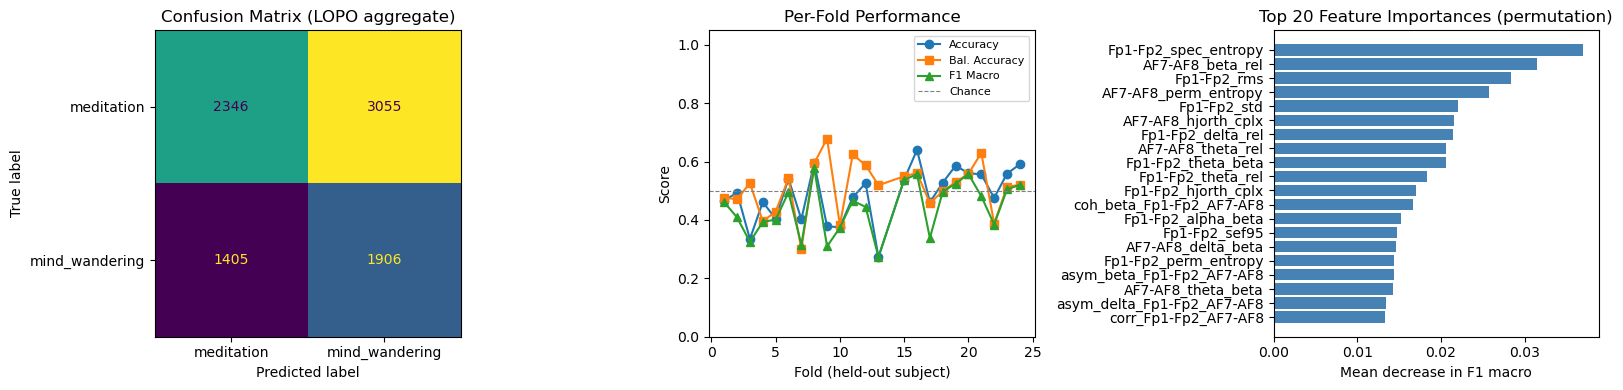

Saved lopo_results.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=TARGET_LABELS)
ConfusionMatrixDisplay(cm, display_labels=TARGET_LABELS).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (LOPO aggregate)")

# Per-fold metrics
axes[1].plot(folds_df["fold"], folds_df["accuracy"],     "o-", label="Accuracy")
axes[1].plot(folds_df["fold"], folds_df["balanced_acc"], "s-", label="Bal. Accuracy")
axes[1].plot(folds_df["fold"], folds_df["f1_macro"],     "^-", label="F1 Macro")
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Chance")
axes[1].set_xlabel("Fold (held-out subject)")
axes[1].set_ylabel("Score")
axes[1].set_title("Per-Fold Performance")
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 1.05)

# Feature importance via permutation (model-agnostic, works for SVC)
print("Computing permutation importance (may take ~1 min)...")
final_model = make_pipeline()
final_model.fit(X_sess, y)
perm = permutation_importance(
    final_model, X_sess, y,
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1, scoring="f1_macro",
)
importances = perm.importances_mean
top_n  = 20
top_idx = np.argsort(importances)[::-1][:top_n]
axes[2].barh([feat_names[i] for i in top_idx[::-1]],
             importances[top_idx[::-1]], color="steelblue")
axes[2].set_title(f"Top {top_n} Feature Importances (permutation)")
axes[2].set_xlabel("Mean decrease in F1 macro")

plt.tight_layout()
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(ARTIFACTS_DIR / "lopo_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved lopo_results.png")

## Threshold Tuning

SVC with `probability=True` outputs calibrated probabilities. The default threshold of 0.5 often underpredicts the minority class. Sweeping the threshold using the LOPO-collected probabilities finds the value that maximises F1 macro without re-training.

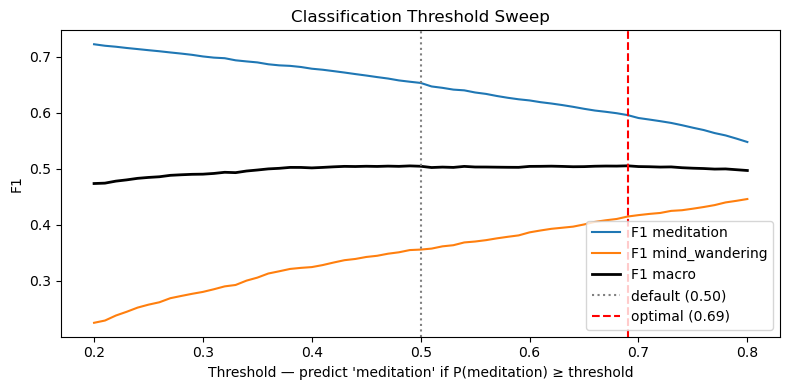

Default  threshold (0.50) → F1 macro: 0.505
Optimal  threshold (0.69) → F1 macro: 0.505  (+0.001)

--- Report at default threshold (0.50) ---
                precision    recall  f1-score   support

    meditation       0.63      0.43      0.51      5401
mind_wandering       0.38      0.58      0.46      3311

      accuracy                           0.49      8712
     macro avg       0.50      0.51      0.49      8712
  weighted avg       0.53      0.49      0.49      8712

--- Report at optimal threshold (0.69) ---
                precision    recall  f1-score   support

    meditation       0.63      0.57      0.60      5401
mind_wandering       0.39      0.45      0.41      3311

      accuracy                           0.52      8712
     macro avg       0.51      0.51      0.51      8712
  weighted avg       0.54      0.52      0.53      8712



In [13]:
# Sweep classification threshold using LOPO-collected probabilities.
# Default threshold (0.5) may underpredict meditation — tuning balances per-class F1.
thresholds = np.linspace(0.2, 0.8, 61)
f1_med, f1_mw, f1_mac = [], [], []
y_proba_arr = np.array(y_proba)

for t in thresholds:
    y_pred_t = np.where(y_proba_arr >= t, "meditation", "mind_wandering")
    f1_med.append(f1_score(y_true, y_pred_t, pos_label="meditation",     zero_division=0))
    f1_mw.append( f1_score(y_true, y_pred_t, pos_label="mind_wandering", zero_division=0))
    f1_mac.append(f1_score(y_true, y_pred_t, average="macro",            zero_division=0))

best_t   = thresholds[np.argmax(f1_mac)]
best_f1  = max(f1_mac)
default_f1 = f1_mac[np.argmin(np.abs(thresholds - 0.5))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_med, label="F1 meditation")
ax.plot(thresholds, f1_mw,  label="F1 mind_wandering")
ax.plot(thresholds, f1_mac, label="F1 macro", linewidth=2, color="black")
ax.axvline(0.5,    color="gray", linestyle=":",  label="default (0.50)")
ax.axvline(best_t, color="red",  linestyle="--", label=f"optimal ({best_t:.2f})")
ax.set_xlabel("Threshold — predict 'meditation' if P(meditation) ≥ threshold")
ax.set_ylabel("F1")
ax.set_title("Classification Threshold Sweep")
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "threshold_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Default  threshold (0.50) → F1 macro: {default_f1:.3f}")
print(f"Optimal  threshold ({best_t:.2f}) → F1 macro: {best_f1:.3f}  (+{best_f1 - default_f1:.3f})")

# Classification report at optimal threshold
y_pred_tuned = np.where(y_proba_arr >= best_t, "meditation", "mind_wandering")
print(f"\n--- Report at default threshold (0.50) ---")
print(classification_report(y_true, y_pred, target_names=TARGET_LABELS, zero_division=0))
print(f"--- Report at optimal threshold ({best_t:.2f}) ---")
print(classification_report(y_true, y_pred_tuned, target_names=TARGET_LABELS, zero_division=0))

Probe-level evaluation: 792 probes  (from 8712 windows, avg 11.0 windows/probe)

--- Probe-level @ default threshold (0.50) ---
                precision    recall  f1-score   support

    meditation       0.63      0.75      0.68       491
mind_wandering       0.41      0.28      0.33       301

      accuracy                           0.57       792
     macro avg       0.52      0.51      0.51       792
  weighted avg       0.54      0.57      0.55       792

--- Probe-level @ tuned threshold (0.69) ---
                precision    recall  f1-score   support

    meditation       0.63      0.53      0.57       491
mind_wandering       0.39      0.50      0.44       301

      accuracy                           0.52       792
     macro avg       0.51      0.51      0.51       792
  weighted avg       0.54      0.52      0.52       792



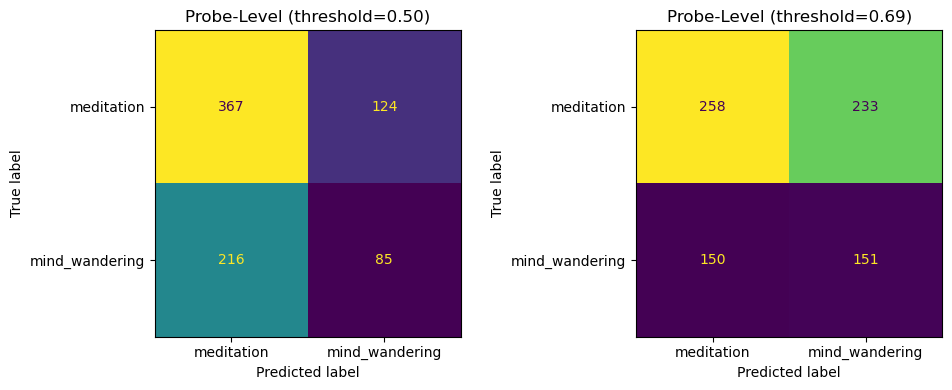

In [14]:
## Probe-Level Results
# Each probe event produced 11 sliding windows. Aggregate window-level
# probabilities to one decision per probe — this mirrors how the firmware works:
# collect all windows in the 10s buffer, average P(meditation), then decide.
from collections import defaultdict

probe_proba_lists: dict = defaultdict(list)
probe_true_label:  dict = {}
for pid, label, proba in zip(probe_ids_out, y_true, y_proba):
    probe_proba_lists[pid].append(proba)
    probe_true_label[pid] = label

probe_ids_u   = list(probe_true_label.keys())
probe_labels  = np.array([probe_true_label[p]           for p in probe_ids_u])
probe_probas  = np.array([np.mean(probe_proba_lists[p]) for p in probe_ids_u])

probe_preds_default = np.where(probe_probas >= 0.5,    "meditation", "mind_wandering")
probe_preds_tuned   = np.where(probe_probas >= best_t, "meditation", "mind_wandering")

print(f"Probe-level evaluation: {len(probe_ids_u)} probes  "
      f"(from {len(y_true)} windows, avg {len(y_true)/len(probe_ids_u):.1f} windows/probe)")
print()
print("--- Probe-level @ default threshold (0.50) ---")
print(classification_report(probe_labels, probe_preds_default,
                             target_names=TARGET_LABELS, zero_division=0))
print(f"--- Probe-level @ tuned threshold ({best_t:.2f}) ---")
print(classification_report(probe_labels, probe_preds_tuned,
                             target_names=TARGET_LABELS, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, preds, title in [
    (axes[0], probe_preds_default, "Probe-Level (threshold=0.50)"),
    (axes[1], probe_preds_tuned,   f"Probe-Level (threshold={best_t:.2f})"),
]:
    cm = confusion_matrix(probe_labels, preds, labels=TARGET_LABELS)
    ConfusionMatrixDisplay(cm, display_labels=TARGET_LABELS).plot(ax=ax, colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "probe_level_cm.png", dpi=150, bbox_inches="tight")
plt.show()

## Real-Time Benchmark

Measure feature extraction and SVM inference time on this machine, then estimate latency on the nRF54L15 (Cortex-M33 @ 128 MHz) using known CMSIS-DSP cycle counts for `arm_rfft_fast_f32`.

In [15]:
# Benchmark feature extraction to show real-time viability on nRF54L15 (Cortex-M33)
n_ch       = len(channel_names)
n_pairs    = n_ch * (n_ch - 1) // 2
sample_seg = np.random.randn(n_ch, int(fs * WINDOW_SEC)).astype(np.float32)

N = 200
t0 = time.perf_counter()
for _ in range(N):
    extract_features(sample_seg, fs)
pc_ms = (time.perf_counter() - t0) / N * 1000

# Time SVM inference separately
N_inf = 500
sample_feat = extract_features(sample_seg, fs).reshape(1, -1)
t0 = time.perf_counter()
for _ in range(N_inf):
    final_model.predict_proba(sample_feat)
infer_ms = (time.perf_counter() - t0) / N_inf * 1000

# nRF54L15 Cortex-M33 @ 128 MHz estimate with CMSIS-DSP
# arm_rfft_fast_f32(256) ≈ 1000 cycles ≈ 8 µs at 128 MHz
# Welch on WINDOW_SEC: ceil(2*WINDOW_SEC) segments per channel
n_segments   = math.ceil(2 * WINDOW_SEC)
fft_us       = n_segments * n_ch * 8    # per-channel Welch FFTs
scalar_us    = 200                       # band sums, Hjorth, ratios, ZCR, log-asymmetry, SEF95 (2 ch)
pe_us        = n_ch * 150               # permutation entropy O(n) per channel
svm_us       = 800                       # O(n_support × n_features)
m33_total_ms = (fft_us + scalar_us + pe_us + svm_us) / 1000

budget_ms = WINDOW_SEC * 1000
headroom  = budget_ms - m33_total_ms

print(f"Channels: {n_ch}  |  pairs: {n_pairs}  |  features: {len(feat_names)}")
print(f"Feature extraction  PC (Python):        {pc_ms:.1f} ms")
print(f"SVM inference       PC (Python):        {infer_ms:.2f} ms")
print()
print(f"M33 estimate (CMSIS-DSP arm_rfft_fast_f32):")
print(f"  FFT  ({n_segments} segs × {n_ch} ch × 8 µs):        {fft_us} µs")
print(f"  Scalar ops (bands, Hjorth, SEF95):      {scalar_us} µs")
print(f"  Permutation entropy ({n_ch} ch):          {pe_us} µs")
print(f"  SVM inference:                          {svm_us} µs")
print(f"  Total:                                  {m33_total_ms:.1f} ms")
print()
print(f"Window budget:  {budget_ms:.0f} ms")
print(f"Headroom:       {headroom:.0f} ms  ({headroom/budget_ms*100:.0f}% of budget remaining)")
print(f"Real-time viable: {'YES' if headroom > 0 else 'NO'}")

Channels: 2  |  pairs: 1  |  features: 82
Feature extraction  PC (Python):        23.5 ms
SVM inference       PC (Python):        1.90 ms

M33 estimate (CMSIS-DSP arm_rfft_fast_f32):
  FFT  (10 segs × 2 ch × 8 µs):        160 µs
  Scalar ops (bands, Hjorth, SEF95):      200 µs
  Permutation entropy (2 ch):          300 µs
  SVM inference:                          800 µs
  Total:                                  1.5 ms

Window budget:  5000 ms
Headroom:       4999 ms  (100% of budget remaining)
Real-time viable: YES


## Firmware-Viable Feature Set

Drop the 3 coherence features (`coh_theta`, `coh_alpha`, `coh_beta`): they require cross-spectrum computation (`arm_cmplx_mult_cmplx_f32` + magnitude-squared per bin), which is non-trivial firmware code. Lateralization is already captured by the log-asymmetry features (`asym_*`), which are just `log(P_Fp2) − log(P_Fp1)` computed from band powers already in hand.

All remaining 61 features use only `arm_rfft_fast_f32` + scalar arithmetic (`CONFIG_CMSIS_DSP=y`).

In [16]:
# Coherence requires cross-spectrum computation (arm_cmplx_mult_cmplx_f32 + magnitude-squared
# per bin) for every pair — significant firmware complexity vs. log-asymmetry which is just
# log(P_j) - log(P_i) from band powers already in hand. Drop all coh_* features.
FW_EXCLUDE    = {n for n in feat_names if n.startswith("coh_")}
fw_feat_names = [n for n in feat_names if n not in FW_EXCLUDE]
fw_mask       = np.array([n not in FW_EXCLUDE for n in feat_names])
X_fw          = X_sess[:, fw_mask]

n_pairs = len(channel_names) * (len(channel_names) - 1) // 2
print(f"Full model:     {len(feat_names)} features  ({n_pairs} pairs × 3 coh + rest)")
print(f"Firmware model: {len(fw_feat_names)} features  (dropped {len(FW_EXCLUDE)} coherence features)")
print()

print("Running LOPO for firmware feature set...")
fw_fold_results, fw_y_true, fw_y_pred, _, _ = run_lopo(X_fw, y, groups)
fw_df = pd.DataFrame(fw_fold_results)

print()
print(f"{'Metric':<20} {'Full model':>12} {'Firmware':>10} {'Delta':>8}")
print("-" * 52)
for col, label in [("accuracy", "Accuracy"), ("balanced_acc", "Balanced Acc"), ("f1_macro", "F1 Macro")]:
    full_val = folds_df[col].mean()
    fw_val   = fw_df[col].mean()
    print(f"{label:<20} {full_val:>12.3f} {fw_val:>10.3f} {fw_val - full_val:>+8.3f}")

Full model:     82 features  (1 pairs × 3 coh + rest)
Firmware model: 79 features  (dropped 3 coherence features)

Running LOPO for firmware feature set...
  Fold  1 | held-out: sub-001 | acc=0.461 | bal_acc=0.493 | F1=0.461 | rec_med=0.38 | rec_mw=0.60
  Fold  2 | held-out: sub-002 | acc=0.524 | bal_acc=0.511 | F1=0.435 | rec_med=0.53 | rec_mw=0.49
  Fold  3 | held-out: sub-003 | acc=0.334 | bal_acc=0.526 | F1=0.325 | rec_med=0.14 | rec_mw=0.91
  Fold  4 | held-out: sub-004 | acc=0.448 | bal_acc=0.418 | F1=0.401 | rec_med=0.47 | rec_mw=0.36
  Fold  5 | held-out: sub-005 | acc=0.396 | bal_acc=0.428 | F1=0.395 | rec_med=0.33 | rec_mw=0.52
  Fold  6 | held-out: sub-006 | acc=0.579 | bal_acc=0.596 | F1=0.535 | rec_med=0.57 | rec_mw=0.63
  Fold  7 | held-out: sub-007 | acc=0.382 | bal_acc=0.306 | F1=0.310 | rec_med=0.41 | rec_mw=0.20
  Fold  8 | held-out: sub-008 | acc=0.644 | bal_acc=0.648 | F1=0.628 | rec_med=0.64 | rec_mw=0.66
  Fold  9 | held-out: sub-009 | acc=0.369 | bal_acc=0.674 | 

In [17]:
# Train final firmware model on reduced feature set and export
fw_final = make_pipeline()
fw_final.fit(X_fw, y)
n_fw_features = len(fw_feat_names)

fw_onnx = convert_sklearn(
    fw_final,
    initial_types=[("input", FloatTensorType([None, n_fw_features]))],
)
fw_onnx_path = ARTIFACTS_DIR / "meditation_model_fw.onnx"
fw_onnx_path.write_bytes(fw_onnx.SerializeToString())

fw_schema = {
    "input_name":    "input",
    "dtype":         "float32",
    "window_sec":    WINDOW_SEC,
    "sampling_rate_hz": float(fs),
    "channel_names": list(channel_names),
    "n_features":    n_fw_features,
    "feature_names": fw_feat_names,
    "excluded_vs_full": sorted(FW_EXCLUDE),
    "classification_threshold": float(best_t),
    "zephyr_note": (
        "All features computable with CONFIG_CMSIS_DSP=y. "
        "Use arm_rfft_fast_f32(256) for Welch PSD segments, then scalar band summation. "
        "Coherence dropped — lateralization captured by log-asymmetry features instead."
    ),
    "outputs": TARGET_LABELS,
}
fw_schema_path = ARTIFACTS_DIR / "feature_schema_fw.json"
fw_schema_path.write_text(json.dumps(fw_schema, indent=2), encoding="utf-8")
print(f"Firmware ONNX saved:   {fw_onnx_path}")
print(f"Firmware schema saved: {fw_schema_path}")

NotImplementedError: No registered models, no known allowed options for model 'Pipeline'.

In [18]:
## TypeScript / React Native — FW ONNX Test Vectors
#
# Exports two session-normalized feature vectors (one per class) that can be
# fed directly into meditation_model_fw.onnx from TypeScript/React Native.
# Also exports per-subject normalization parameters so the app can reproduce
# the same z-score step at inference time.
#
# Usage in TypeScript (onnxruntime-react-native):
#   import testData from './fw_onnx_test_data.json';
#   const session = await InferenceSession.create('meditation_model_fw.onnx');
#   const input = new Tensor('float32', testData.examples[0].features, [1, testData.n_features]);
#   const { label } = await session.run({ input });

np.random.seed(RANDOM_STATE)

# Pick one verified-correct example per class from all-data predictions
# (fw_final is trained on all data, so these are in-sample — fine for a smoke test)
med_candidates = np.where(y == "meditation")[0]
mw_candidates  = np.where(y == "mind_wandering")[0]

def _pick_correct(candidates, target_label):
    """Return X_fw row index where fw_final predicts correctly."""
    np.random.shuffle(candidates)
    for i in candidates:
        if fw_final.predict(X_fw[i:i+1])[0] == target_label:
            return i
    return candidates[0]  # fallback

med_idx = _pick_correct(med_candidates, "meditation")
mw_idx  = _pick_correct(mw_candidates,  "mind_wandering")

med_proba = float(fw_final.predict_proba(X_fw[med_idx:med_idx+1])[0,
                  list(fw_final.classes_).index("meditation")])
mw_proba  = float(fw_final.predict_proba(X_fw[mw_idx:mw_idx+1])[0,
                  list(fw_final.classes_).index("meditation")])

examples = [
    {
        "label":       "meditation",
        "subject":     str(groups[med_idx]),
        "p_meditation": round(med_proba, 4),
        "features":    X_fw[med_idx].tolist(),
    },
    {
        "label":       "mind_wandering",
        "subject":     str(groups[mw_idx]),
        "p_meditation": round(mw_proba, 4),
        "features":    X_fw[mw_idx].tolist(),
    },
]

# Per-subject normalization parameters for the app's session z-score step
norm_params = {}
for subj in np.unique(groups):
    mask  = groups == subj
    block = X[mask].astype(np.float64)
    mu    = block.mean(axis=0)
    std   = block.std(axis=0)
    std[std < 1e-8] = 1.0
    # Export only the FW-feature subset
    norm_params[subj] = {
        "mean": mu[fw_mask].tolist(),
        "std":  std[fw_mask].tolist(),
    }

ts_data = {
    "description": (
        "FW ONNX smoke-test data for TypeScript/React Native. "
        "Features are already session-z-scored. "
        "Pass features directly to meditation_model_fw.onnx as float32 input."
    ),
    "model_file":               "meditation_model_fw.onnx",
    "n_features":               len(fw_feat_names),
    "feature_names":            fw_feat_names,
    "classification_threshold": float(best_t),
    "labels":                   TARGET_LABELS,
    "inference_note": (
        "At runtime: (1) compute bipolar EEG derivations (Fp1-Fp2)-Fpz and (AF7-AF8)-Fpz, "
        "(2) extract features via the firmware feature pipeline, "
        "(3) subtract session mean and divide by session std per feature, "
        "(4) feed the float32 vector to the ONNX model, "
        "(5) if output_probability >= classification_threshold → 'meditation' else 'mind_wandering'."
    ),
    "examples":    examples,
    "session_normalization_params": norm_params,
}

ts_json_path = ARTIFACTS_DIR / "fw_onnx_test_data.json"
ts_json_path.write_text(json.dumps(ts_data, indent=2), encoding="utf-8")
print(f"TypeScript test data saved: {ts_json_path}")

# Also write a .ts file with typed constants for direct import
ts_lines = [
    "// Auto-generated by meditation.ipynb — do not edit by hand.",
    "// Feed testVectors directly to meditation_model_fw.onnx for smoke-testing.",
    "",
    f"export const FW_N_FEATURES = {len(fw_feat_names)};",
    f"export const FW_THRESHOLD  = {best_t:.4f};  "
        "// P(meditation) >= threshold → 'meditation'",
    "export type MeditationLabel = 'meditation' | 'mind_wandering';",
    "",
    "export interface FwTestVector {",
    "  label:        MeditationLabel;",
    "  pMeditation:  number;",
    "  features:     number[];   // session-z-scored, length = FW_N_FEATURES",
    "}",
    "",
    "export const FW_TEST_VECTORS: FwTestVector[] = [",
]
for ex in examples:
    feat_str = ", ".join(f"{v:.6f}" for v in ex["features"])
    ts_lines += [
        "  {",
        f"    label:       '{ex['label']}',",
        f"    pMeditation:  {ex['p_meditation']},",
        f"    features:    [{feat_str}],",
        "  },",
    ]
ts_lines += ["];", ""]

ts_file_path = ARTIFACTS_DIR / "fw_test_vectors.ts"
ts_file_path.write_text("\n".join(ts_lines), encoding="utf-8")
print(f"TypeScript constants saved: {ts_file_path}")
print()
print(f"Meditation example     → P(meditation)={med_proba:.3f}  "
      f"(subject {groups[med_idx]})")
print(f"Mind-wandering example → P(meditation)={mw_proba:.3f}  "
      f"(subject {groups[mw_idx]})")

TypeScript test data saved: artifacts\fw_onnx_test_data.json
TypeScript constants saved: artifacts\fw_test_vectors.ts

Meditation example     → P(meditation)=0.995  (subject sub-011)
Mind-wandering example → P(meditation)=0.161  (subject sub-022)


## Export — ONNX Model & Feature Schema

In [ ]:
# ONNX export
onnx_model = convert_sklearn(
    final_model,
    initial_types=[("input", FloatTensorType([None, n_features]))],
)
onnx_path = ARTIFACTS_DIR / "meditation_model_snoozy.onnx"
onnx_path.write_bytes(onnx_model.SerializeToString())
print(f"ONNX model saved: {onnx_path}")

# Joblib export (for quick Python inference during development)
joblib_path = ARTIFACTS_DIR / "meditation_model_snoozy.joblib"
joblib.dump(final_model, joblib_path)
print(f"Joblib model saved: {joblib_path}")

# Feature schema for the Snoozy firmware / app
schema = {
    "input_name": "input",
    "dtype": "float32",
    "window_sec": WINDOW_SEC,
    "sampling_rate_hz": float(fs),
    "channel_names": list(channel_names),
    "hardware_referencing": (
        "Two bipolar EEG derivations: (Fp1−Fp2)−Fpz and (AF7−AF8)−Fpz. "
        "ADS1299-4 Ch1: A(Fp1) − B(Fp2), Ch2: A(AF7) − B(AF8), BIAS/REF: Fpz. "
        "Subtract the Fpz sample from each bipolar output before feature extraction."
    ),
    "n_features": n_features,
    "feature_names": feat_names,
    "bands_hz": {k: list(v) for k, v in BANDS.items()},
    "sub_bands_hz": {k: list(v) for k, v in SUB_BANDS.items()},
    "bandpass_hz": [LOWCUT, HIGHCUT],
    "classification_threshold": float(best_t),
    "outputs": TARGET_LABELS,
    "lopo_cv": {
        "mean_accuracy":     float(folds_df["accuracy"].mean()),
        "std_accuracy":      float(folds_df["accuracy"].std()),
        "mean_balanced_acc": float(folds_df["balanced_acc"].mean()),
        "mean_f1_macro":     float(folds_df["f1_macro"].mean()),
        "mean_recall_mw":    float(folds_df["recall_mw"].mean()),
        "n_subjects":        int(len(folds_df)),
    },
    "notes": (
        "Binary meditation vs. mind_wandering classifier for Snoozy (nRF54L15 + ADS1299-4). "
        "Input to ONNX is the engineered feature vector, not raw EEG. "
        f"Features extracted from {len(channel_names)}-channel {WINDOW_SEC:.0f}s EEG window. "
        "Trained on OpenNeuro ds001787 with LOPO CV. "
        "Use classification_threshold instead of 0.5 — tuned to maximise F1 macro."
    ),
}

schema_path = ARTIFACTS_DIR / "feature_schema_snoozy.json"
schema_path.write_text(json.dumps(schema, indent=2), encoding="utf-8")
print(f"Feature schema saved: {schema_path}")

ONNX model saved: artifacts\meditation_model_snoozy.onnx
Joblib model saved: artifacts\meditation_model_snoozy.joblib
Feature schema saved: artifacts\feature_schema_snoozy.json


## Sanity Check — ONNX Inference

In [ ]:
import onnxruntime as ort

sess = ort.InferenceSession(str(onnx_path))
input_name  = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name

# Use session-normalized features — the model was trained on X_sess
sample = X_sess[:1].astype(np.float32)
sklearn_pred = final_model.predict(sample)[0]
onnx_pred    = sess.run([output_name], {input_name: sample})[0][0]

print(f"sklearn prediction : {sklearn_pred}")
print(f"ONNX   prediction  : {onnx_pred}")
assert sklearn_pred == onnx_pred, "Prediction mismatch between sklearn and ONNX!"
print("ONNX sanity check passed.")
print(f"\nONNX input shape expected: [batch, {n_features}]")
print(f"Note: features must be session-z-scored before inference (subtract session mean, divide by session std)")

sklearn prediction : mind_wandering
ONNX   prediction  : mind_wandering
ONNX sanity check passed.

ONNX input shape expected: [batch, 78]
Note: features must be session-z-scored before inference (subtract session mean, divide by session std)
